In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os

In [2]:
output_folder=("../PhysiCell/results/fixed_cell_cycle/cell_volumes.csv")
pc_df = pd.read_csv(output_folder,float_precision='round_trip').sort_values(by=['dt']).reset_index(drop=True)

output_folder=("../Biodynamo/unit_test_cellcycle/new_results/cell-0-sim1.csv")
bd_df = pd.read_csv(output_folder,header=None)
bd_df.columns = ['timestep', 'volume', 'Phase', 'Age']
bd_df['vol']= bd_df['volume']/bd_df['volume'][0]

output_folder=("../Chaste/unit_test_cellcycle/results/cellcycle_fixed.dat")
ch_df = pd.DataFrame(columns=["dt","id","x","y","z","g1_duration","s_duration","g2_duration","m_duration","current_phase","target_area","volume"])
with open(output_folder, "r") as f:
    for line in f.read().splitlines():
        data = line.split()
        data = [float(x) if x.replace('.', '', 1).isdigit() else x for x in data]
        dt = data[0]
        for i in range(0,len(data)//11):
            row = {'dt': dt, 'id': data[1+11*i], 'x': data[2+11*i], 'y': data[3+11*i], 'z': data[4+11*i], 'g1_duration': data[5+11*i], 's_duration': data[6+11*i], 'g2_duration': data[7+11*i], 'm_duration': data[8+11*i], 'current_phase': data[9+11*i], 'target_area': data[10+11*i], 'volume': data[11+11*i]}
            row = pd.Series(row)
            df2 = pd.DataFrame(row).transpose()

            ch_df =pd.concat([ch_df,df2],ignore_index=True)

file = "../Tisim/unit_test_cellcycle/cell cycle fix.csv"
data = pd.read_csv(file, header=0)
time_steps = data['time (hour)']
volume_columns = data.columns[1:]  # Assuming all other columns are cell volumes

average_volumes = data[volume_columns].mean(axis=1, skipna=True)
initial_total_volume = average_volumes.iloc[0]

percentage_total_volumes = (average_volumes / initial_total_volume)*100
# print(percentage_total_volumes)
# Create a new DataFrame with time steps and percentage of total volumes
ts_df = pd.DataFrame({
    'timestep': time_steps,
    'volumes': percentage_total_volumes
})

file = "./CCgroundtruth.txt"
exp_df = pd.read_csv(file, header=0, sep="\t")
exp_df = exp_df.iloc[:, 2:4]
exp_df.columns = ['volume','timestep']

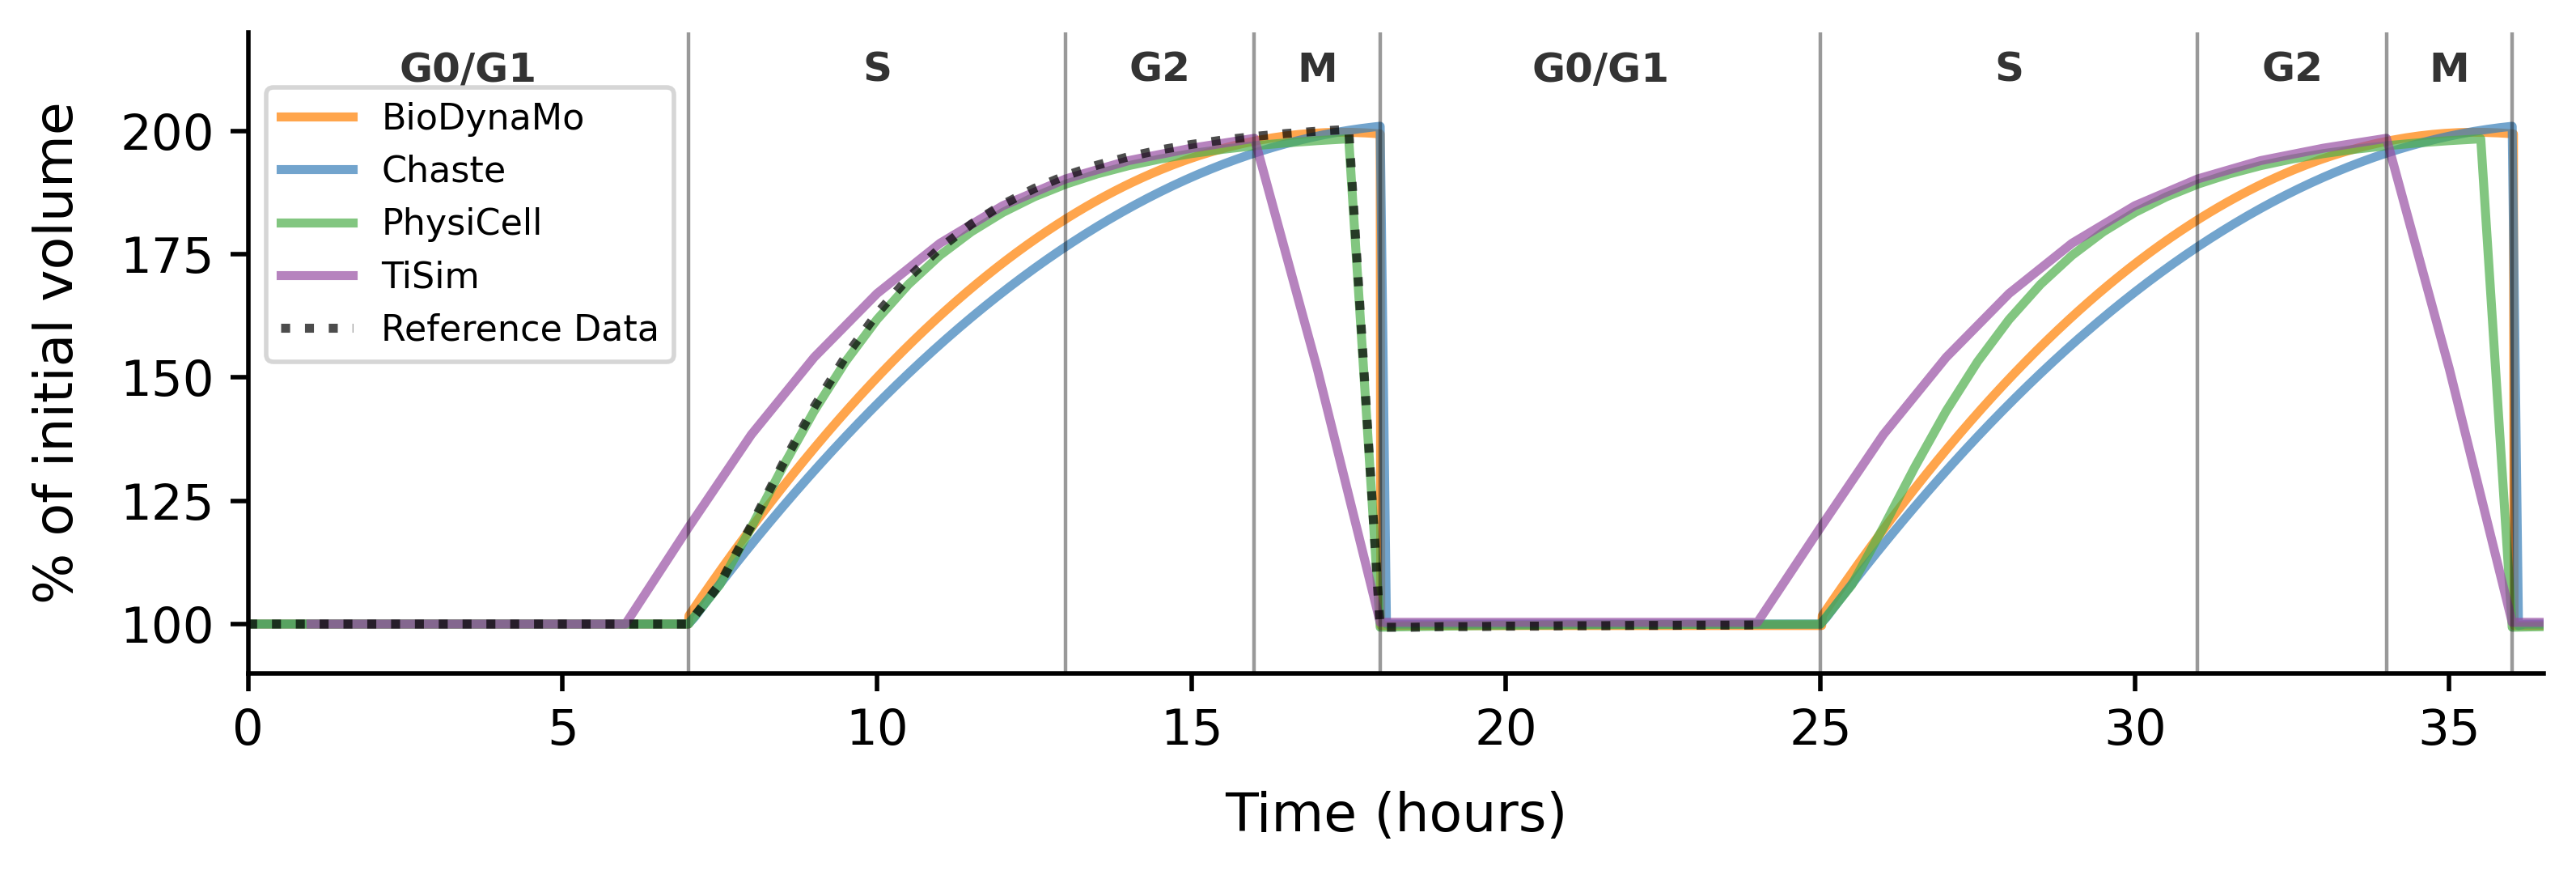

In [3]:
# Update font settings with fallback options
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Helvetica', 'Arial', 'sans-serif'],
    'font.size': 8,  # Base font size
    'axes.labelsize': 9,  # Increased from 8
    'axes.titlesize': 9,  # Increased from 8
    'xtick.labelsize': 8,  # Increased from 7
    'ytick.labelsize': 8,  # Increased from 7
    'legend.fontsize': 8,  # Increased from 7
    'lines.linewidth': 2.0,  # Increased from 1.8
    'axes.linewidth': 1.0,  # Increased from 0.8
    'xtick.major.width': 1.0,  # Increased from 0.8
    'ytick.major.width': 1.0,  # Increased from 0.8
    'xtick.major.size': 4,  # Increased from 3
    'ytick.major.size': 4,  # Increased from 3
    'figure.dpi': 400
})

# Create figure with specific dimensions - made more compact
fig, ax = plt.subplots(figsize=(8, 2.8))  # Match proportions to previous examples

# Normalize time to hours
pc_df['dt'] = pc_df['dt'] / 60
pc_init_vol = pc_df.iloc[0]["total_volume"]

# Compute average volume per time step (normalized)
pc_avg_vol = pc_df.groupby('dt')['total_volume'].mean()
pc_dts = pc_avg_vol.index
pc_vols = (pc_avg_vol / pc_init_vol * 100).tolist()

# Define consistent colors and linestyles
colors = {
    'BioDynaMo': '#ff7f00',   # Orange (changed from red)
    'Chaste': '#377eb8',      # Blue
    'PhysiCell': '#4daf4a',   # Green
    'TiSim': '#984ea3',        # Purple
    'Exp': '#000000'  # Black for experimental data
}

linestyles = {
    'BioDynaMo': '-',   # Solid
    'Chaste': '-',     # Solid
    'PhysiCell': '-',  # Solid
    'TiSim': '-',        # Solid
    'Exp': 'dotted'  # Dotted for experimental data
}
labels = {
    'PhysiCell': 'PhysiCell',
    'BioDynaMo': 'BioDynaMo',
    'Chaste': 'Chaste',
    'TiSim': 'TiSim',
    'Exp': 'Reference Data'
}

# Plot all simulators with consistent styling
# BioDynaMo
ax.plot(bd_df['timestep'], bd_df["vol"] * 100, 
        color=colors['BioDynaMo'], 
        linestyle=linestyles['BioDynaMo'], 
        label=labels['BioDynaMo'],
        linewidth=2.0,
        alpha=0.7)

# Chaste
ch_init_vol = ch_df.loc[0, "volume"]
ch_avg_vol = ch_df.groupby('dt')['volume'].mean()
dts = ch_avg_vol.index
vols = (ch_avg_vol / ch_init_vol * 100).tolist()
ax.plot(dts, vols, 
        color=colors['Chaste'], 
        linestyle=linestyles['Chaste'], 
        label=labels['Chaste'],
        linewidth=2.0,
        alpha=0.7)

# PhysiCell
ax.plot(pc_dts, pc_vols, 
        color=colors['PhysiCell'], 
        linestyle=linestyles['PhysiCell'], 
        label=labels['PhysiCell'],
        linewidth=2.0,
        alpha=0.7)

# TiSim
ax.plot(ts_df['timestep'], ts_df['volumes'], 
        color=colors['TiSim'], 
        linestyle=linestyles['TiSim'], 
        label=labels['TiSim'],
        linewidth=2.0,
        alpha=0.7)

# Experimental Data
ax.plot(exp_df['timestep'], exp_df["volume"],
        color=colors['Exp'], 
        linestyle=linestyles['Exp'], 
        label=labels['Exp'],
        linewidth=2.0,
        alpha=0.7)

        
# Add vertical bars to separate phases
for i in range(3):  # keep 3 cycles for the phase names
    base = 18 * i
    phases = [
        (base, 7, 'G0/G1'),
        (base + 7, 6, 'S'),
        (base + 13, 3, 'G2'),
        (base + 16, 2, 'M'),
    ]
    for x, w, label in phases:
        # Only add text if the phase block is within the plot limits
        if x + w <= 36:
            # Center text in each phase block with increased font size
            ax.text(x + w/2, 210, label, 
                   color='black',
                   alpha=0.8,  # Increased from 0.7
                   fontsize=9,  # Increased from 8
                   ha='center',
                   fontweight='bold')
            # Add vertical bar at the end of each phase with increased width
            ax.axvline(x=x + w, color='black', linestyle='-', linewidth=0.8, alpha=0.4)  # Increased linewidth and alpha

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Remove grid
ax.grid(False)

# Add legend
ax.legend(loc='center left', bbox_to_anchor=(0, 0.7), fontsize=8)

# Set axis limits and labels with increased padding and font size
ax.set_xlim(0, 36.5)
ax.set_ylim(90, 220)
ax.set_xlabel("Time (hours)", labelpad=8, fontsize=12)
ax.set_ylabel("% of initial volume", labelpad=8, fontsize=12)

# Set tick label size
ax.tick_params(axis='both', which='major', labelsize=11)

# Adjust layout
plt.tight_layout()

# Save in vector and raster formats
save_dir = "./"
os.makedirs(save_dir, exist_ok=True)

# Save as PDF
# plt.savefig(os.path.join(save_dir, "fixed_cell_cycle_volumes.pdf"), 
#             format='pdf',
#             bbox_inches='tight', 
#             pad_inches=0.1)
# Save as SVG
# plt.savefig(os.path.join(save_dir, "fixed_cell_cycle_volumes.svg"), 
#             format='svg',
#             bbox_inches='tight', 
#             pad_inches=0.1)

# Save as PNG with high DPI
plt.savefig(os.path.join(save_dir, "fixed_cell_cycle_volumes.png"), 
            dpi=600, 
            bbox_inches='tight', 
            pad_inches=0.1,
            format='png')